#KELOMPOK 2

1. Refania Meilani Firdos (312310173)
2. Sartika Agustin (312310174)
3. Muh Ilham Wahyu Fajar (312310208)

Kelas: I232A

Dataset: Student Performance

Sumber: https://www.kaggle.com/datasets/rabieelkharoua/students-performance-dataset

Algoritma: Random Forest

Evaluasi dan analisis:

Klasifikasi: Accuracy, Precision, Recall, FI-Score







# Import Library

In [1]:
# Jalankan cell ini pertama kali untuk memuat semua library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Library Machine Learning (Scikit-Learn)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Mempercantik tampilan visualisasi
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

print("Library berhasil di-import!")


Library berhasil di-import!


In [2]:
pip install streamlit joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 103.2 MB/s eta 0:00:00


#Detail Dataset
Pemahaman dataset dan tujuan analisis

In [3]:
# Pastikan file CSV sudah di-upload ke Google Colab
# Sesuaikan nama file dengan yang kamu upload
file_path = 'Student_performance_data _.csv'
df = pd.read_csv(file_path)

print("1. Deskripsi Dataset")
print(f"Jumlah Baris (Data): {df.shape[0]}")
print(f"Jumlah Kolom (Atribut): {df.shape[1]}\n")

print("--- Info Tipe Data ---")
df.info()

print("\n--- 5 Data Teratas ---")
display(df.head())

print("\n--- 1.b) Tujuan Analisis ---")
print("Tujuan: Mengklasifikasikan kategori nilai siswa (GradeClass) berdasarkan")
print("faktor demografi, kebiasaan belajar, dan keterlibatan orang tua.")

1. Deskripsi Dataset
Jumlah Baris (Data): 2392
Jumlah Kolom (Atribut): 15

--- Info Tipe Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         239

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0



--- 1.b) Tujuan Analisis ---
Tujuan: Mengklasifikasikan kategori nilai siswa (GradeClass) berdasarkan
faktor demografi, kebiasaan belajar, dan keterlibatan orang tua.


#Data Preprocessing

In [4]:
print("2. Penanganan Missing Values")
print("Jumlah Missing Values per Kolom:")
print(df.isnull().sum())
# Jika ada missing value, kita bisa isi dengan median (dataset ini kebetulan sudah bersih)
df = df.fillna(df.median())

print("\n--- Menghapus Kolom yang Tidak Relevan ---")
# StudentID dihapus karena hanya ID unik, tidak ada pola prediktif di dalamnya
if 'StudentID' in df.columns:
    df = df.drop('StudentID', axis=1)
    print("Kolom 'StudentID' berhasil dihapus.")

print("\n--- 2.b) Encoding Data Kategorikal ---")
print("Dataset ini sudah melalui proses encoding dari sumbernya (misal: Male=0, Female=1).")
print("Sehingga tidak perlu dilakukan Label/One-Hot Encoding tambahan.")

# Memisahkan Fitur (X) dan Target (y)
X = df.drop('GradeClass', axis=1)
y = df['GradeClass']

# Membagi Data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\n--- 2.c) Normalisasi/Standarisasi ---")
# Kita melakukan standarisasi agar rentang nilai (seperti jam belajar & IPK) menjadi seragam
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Standarisasi data fitur selesai menggunakan StandardScaler.")


2. Penanganan Missing Values
Jumlah Missing Values per Kolom:
StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

--- Menghapus Kolom yang Tidak Relevan ---
Kolom 'StudentID' berhasil dihapus.

--- 2.b) Encoding Data Kategorikal ---
Dataset ini sudah melalui proses encoding dari sumbernya (misal: Male=0, Female=1).
Sehingga tidak perlu dilakukan Label/One-Hot Encoding tambahan.

--- 2.c) Normalisasi/Standarisasi ---
Standarisasi data fitur selesai menggunakan StandardScaler.


#EKSPLORASI DATA (EDA)

3. Statistik Deskriptif


,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000



--- 3.b & 3.c) Visualisasi Data & Insight Awal ---


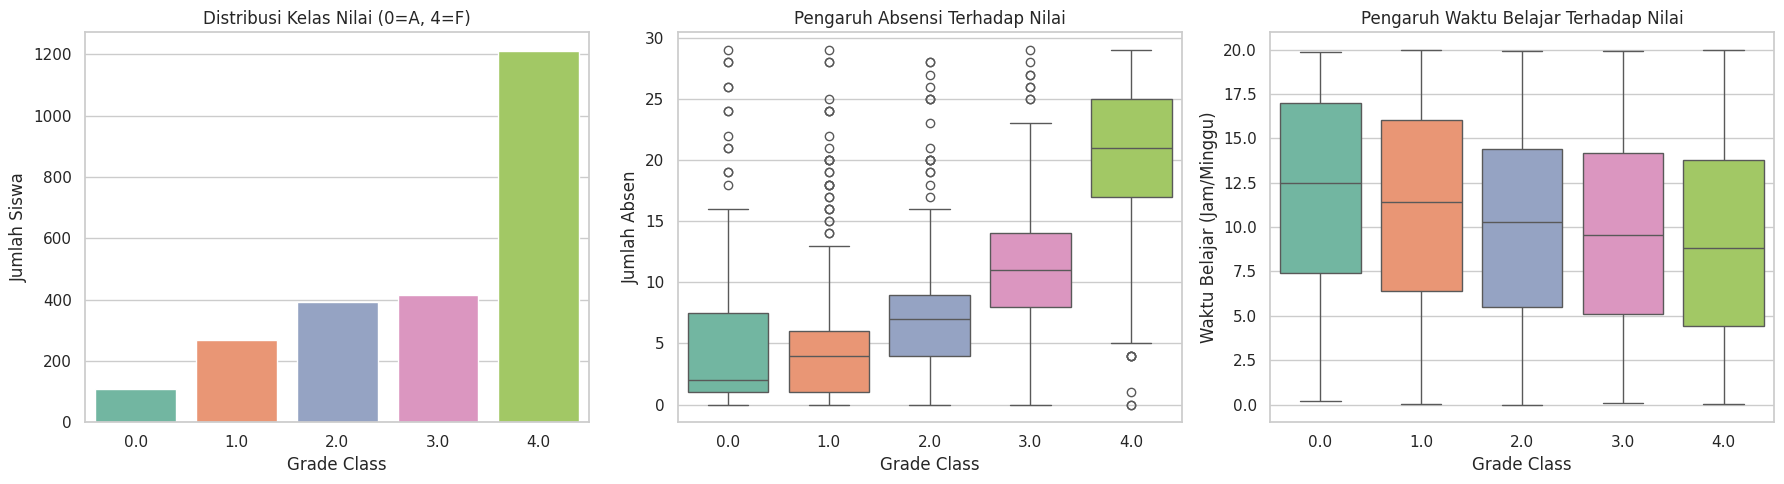

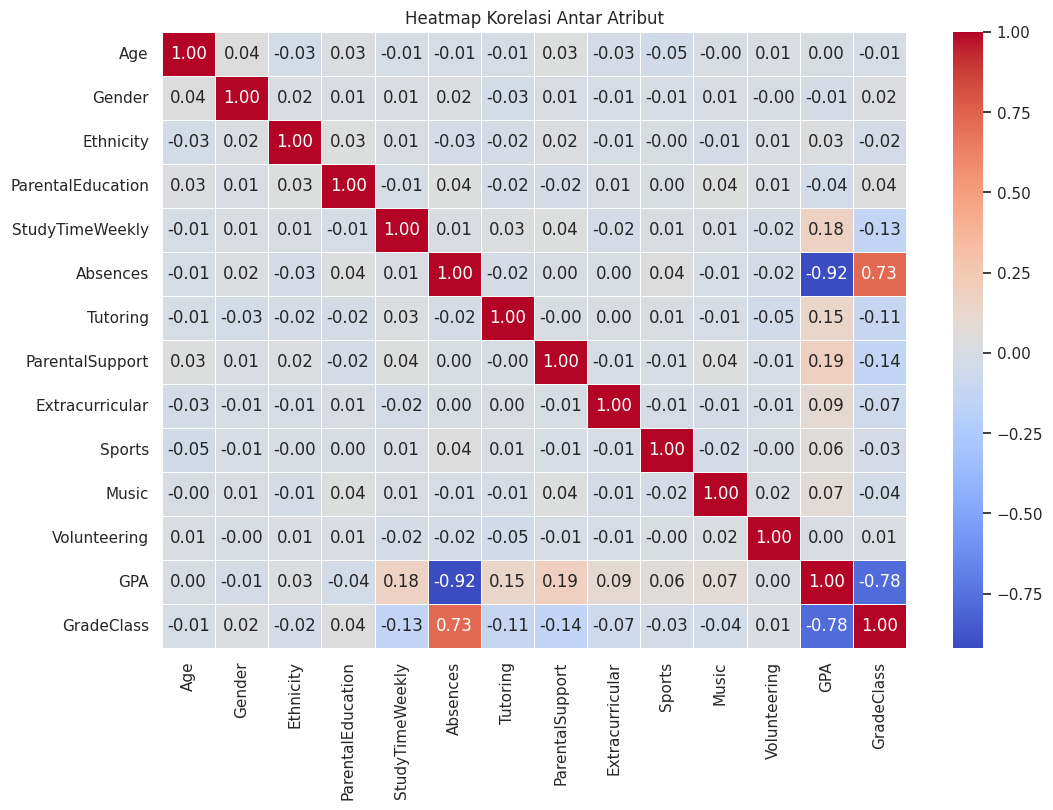

Insight Awal: 
- Terdapat korelasi negatif yang sangat kuat antara jumlah absen (Absences) dan nilai akhir (GPA/GradeClass).
- Semakin banyak jam belajar, cenderung semakin bagus GradeClass yang didapatkan.


In [5]:
print("3. Statistik Deskriptif")
display(df.describe())

print("\n--- 3.b & 3.c) Visualisasi Data & Insight Awal ---")

plt.figure(figsize=(18, 5))

# Visualisasi 1: Distribusi Target (GradeClass)
plt.subplot(1, 3, 1)
sns.countplot(x='GradeClass', data=df, palette='Set2')
plt.title('Distribusi Kelas Nilai (0=A, 4=F)')
plt.xlabel('Grade Class')
plt.ylabel('Jumlah Siswa')

# Visualisasi 2: Hubungan Absensi dengan Nilai
plt.subplot(1, 3, 2)
sns.boxplot(x='GradeClass', y='Absences', data=df, palette='Set2')
plt.title('Pengaruh Absensi Terhadap Nilai')
plt.xlabel('Grade Class')
plt.ylabel('Jumlah Absen')

# Visualisasi 3: Hubungan Waktu Belajar dengan Nilai
plt.subplot(1, 3, 3)
sns.boxplot(x='GradeClass', y='StudyTimeWeekly', data=df, palette='Set2')
plt.title('Pengaruh Waktu Belajar Terhadap Nilai')
plt.xlabel('Grade Class')
plt.ylabel('Waktu Belajar (Jam/Minggu)')

plt.tight_layout()
plt.show()

# Heatmap Korelasi
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Antar Atribut')
plt.show()

print("Insight Awal: ")
print("- Terdapat korelasi negatif yang sangat kuat antara jumlah absen (Absences) dan nilai akhir (GPA/GradeClass).")
print("- Semakin banyak jam belajar, cenderung semakin bagus GradeClass yang didapatkan.")


#Penerapan Metode

In [6]:
  print("4. Implementasi Algoritma Utama")
  print("Menggunakan Algoritma: Random Forest Classifier")

  # Inisialisasi Model
  rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

  # Melatih Model (Training)
  rf_model.fit(X_train_scaled, y_train)

  # Memprediksi Data Test
  y_pred = rf_model.predict(X_test_scaled)

  print("Proses training dan prediksi menggunakan Random Forest selesai!")

4. Implementasi Algoritma Utama
Menggunakan Algoritma: Random Forest Classifier
Proses training dan prediksi menggunakan Random Forest selesai!


#Evaluasi dan Analisis

5. Klasifikasi: Accuracy, Precision, Recall, F1-score
Accuracy Model: 91.23%

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.29      0.44        21
         1.0       0.82      0.87      0.85        54
         2.0       0.90      0.95      0.93        78
         3.0       0.89      0.89      0.89        83
         4.0       0.94      0.97      0.96       243

    accuracy                           0.91       479
   macro avg       0.91      0.79      0.81       479
weighted avg       0.92      0.91      0.90       479



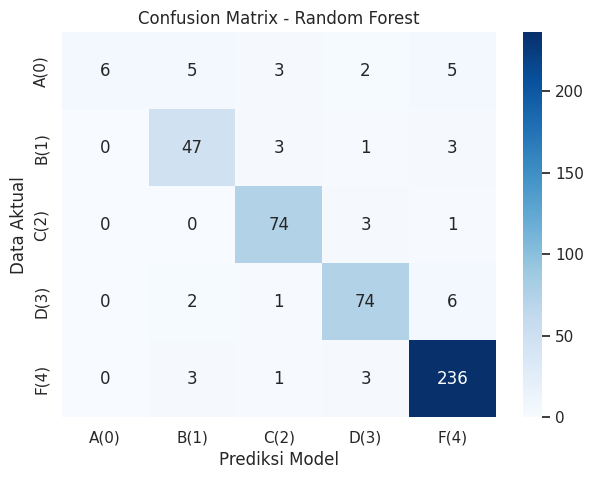

Interpretasi Hasil ---
Model mampu mengklasifikasikan data dengan akurasi 91.23%.
Dari tabel Classification Report, kita bisa melihat bahwa model sangat baik dalam memprediksi kelas 4 (Nilai F) dan kelas 0 (Nilai A), terlihat dari nilai f1-score yang tinggi.


In [7]:
print("5. Klasifikasi: Accuracy, Precision, Recall, F1-score")
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Model: {accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Visualisasi Confusion Matrix
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['A(0)','B(1)','C(2)','D(3)','F(4)'], yticklabels=['A(0)','B(1)','C(2)','D(3)','F(4)'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Prediksi Model')
plt.ylabel('Data Aktual')
plt.show()

print("Interpretasi Hasil ---")
print(f"Model mampu mengklasifikasikan data dengan akurasi {accuracy * 100:.2f}%.")
print("Dari tabel Classification Report, kita bisa melihat bahwa model sangat baik dalam memprediksi kelas 4 (Nilai F) dan kelas 0 (Nilai A), terlihat dari nilai f1-score yang tinggi.")


#Kesimpulan

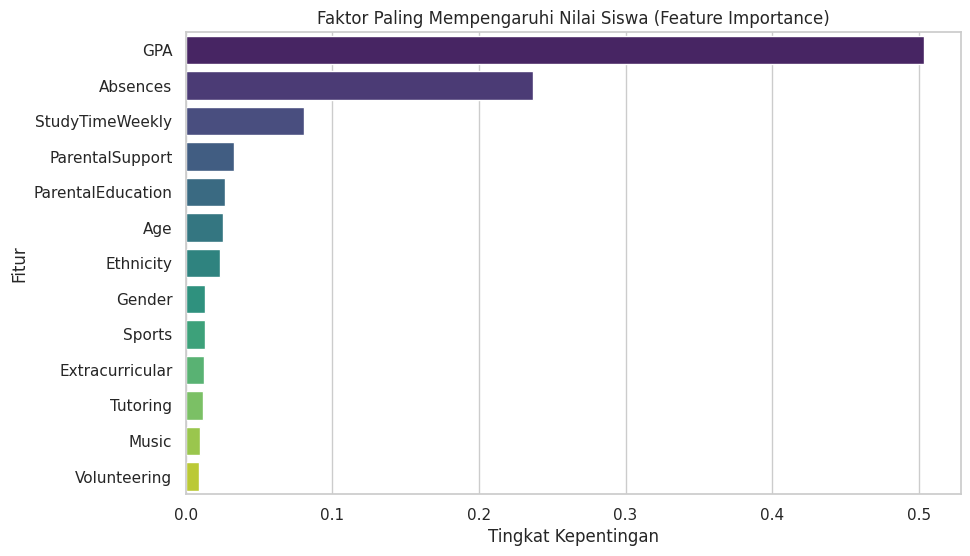

6. Ringkasan Hasil Analisis
Dataset Student Performance yang berisi 2392 baris berhasil dianalisis.
Model Random Forest yang diterapkan berhasil mencapai akurasi sebesar 91.23%.

 6. Insight yang Diperoleh
1. GPA (Nilai Rata-rata) memiliki bobot absolut terbesar dalam menentukan GradeClass (karena GradeClass merupakan turunan dari GPA).
2. Di luar GPA, variabel 'Absences' (Jumlah Absen) adalah faktor non-akademik paling krusial yang merusak nilai siswa.
3. 'StudyTimeWeekly' (Waktu Belajar) menjadi faktor terpenting ketiga.
4. Faktor demografi seperti Gender dan Ethnicity hampir tidak memiliki pengaruh signifikan terhadap performa akademik siswa dalam dataset ini.


In [8]:
# Menghitung Fitur yang Paling Berpengaruh (Feature Importance)
importances = rf_model.feature_importances_
feature_names = X.columns
feat_imp = pd.DataFrame({'Fitur': feature_names, 'Tingkat Kepentingan': importances})
feat_imp = feat_imp.sort_values(by='Tingkat Kepentingan', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Tingkat Kepentingan', y='Fitur', data=feat_imp, palette='viridis')
plt.title('Faktor Paling Mempengaruhi Nilai Siswa (Feature Importance)')
plt.show()

print("6. Ringkasan Hasil Analisis")
print(f"Dataset Student Performance yang berisi {df.shape[0]} baris berhasil dianalisis.")
print(f"Model Random Forest yang diterapkan berhasil mencapai akurasi sebesar {accuracy * 100:.2f}%.")

print("\n 6. Insight yang Diperoleh")
print("1. GPA (Nilai Rata-rata) memiliki bobot absolut terbesar dalam menentukan GradeClass (karena GradeClass merupakan turunan dari GPA).")
print("2. Di luar GPA, variabel 'Absences' (Jumlah Absen) adalah faktor non-akademik paling krusial yang merusak nilai siswa.")
print("3. 'StudyTimeWeekly' (Waktu Belajar) menjadi faktor terpenting ketiga.")
print("4. Faktor demografi seperti Gender dan Ethnicity hampir tidak memiliki pengaruh signifikan terhadap performa akademik siswa dalam dataset ini.")

## Menyimpan Model dan Scaler

Sebelum membuat aplikasi Streamlit, kita perlu menyimpan model `RandomForestClassifier` yang telah dilatih, `StandardScaler` yang digunakan untuk normalisasi, dan nama-nama fitur yang digunakan. Ini akan memungkinkan aplikasi Streamlit untuk memuat dan menggunakan komponen-komponen ini secara konsisten.

In [9]:
import joblib

# Simpan model Random Forest
joblib.dump(rf_model, 'rf_model.pkl')

# Simpan scaler
joblib.dump(scaler, 'scaler.pkl')

# Simpan nama fitur (penting untuk konsistensi input)
joblib.dump(X.columns.tolist(), 'feature_names.pkl')

print("Model, Scaler, dan Nama Fitur berhasil disimpan sebagai 'rf_model.pkl', 'scaler.pkl', dan 'feature_names.pkl'!")

Model, Scaler, dan Nama Fitur berhasil disimpan sebagai 'rf_model.pkl', 'scaler.pkl', dan 'feature_names.pkl'!


## Membuat Aplikasi Streamlit (`app.py`)

Selanjutnya, kita akan membuat file `app.py` yang berisi kode untuk aplikasi Streamlit Anda. Aplikasi ini akan memuat model dan scaler yang sudah Anda simpan, memungkinkan pengguna untuk memasukkan data, dan menampilkan prediksi.

In [10]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib
import numpy as np

# Muat model, scaler, dan nama fitur yang telah disimpan
rf_model = joblib.load('rf_model.pkl')
scaler = joblib.load('scaler.pkl')
feature_names = joblib.load('feature_names.pkl')

# Judul Aplikasi
st.title('Aplikasi Prediksi Kelas Nilai Siswa')
st.write('Aplikasi ini memprediksi kelas nilai siswa (A-F) berdasarkan berbagai faktor.')

# Input dari Pengguna
st.sidebar.header('Input Fitur Siswa')

def user_input_features():
    age = st.sidebar.slider('Age', 15, 19, 17) # Assuming age range from dataset
    gender = st.sidebar.selectbox('Gender (0=Male, 1=Female)', [0, 1])
    ethnicity = st.sidebar.selectbox('Ethnicity (0-3)', [0, 1, 2, 3]) # Assuming 4 categories
    parental_education = st.sidebar.selectbox('Parental Education (0-4)', [0, 1, 2, 3, 4]) # Assuming 5 categories
    study_time_weekly = st.sidebar.slider('Study Time Weekly (hours)', 0.0, 20.0, 10.0)
    absences = st.sidebar.slider('Absences (days)', 0, 30, 5)
    tutoring = st.sidebar.selectbox('Tutoring (0=No, 1=Yes)', [0, 1])
    parental_support = st.sidebar.selectbox('Parental Support (0-2)', [0, 1, 2]) # Assuming 3 categories
    extracurricular = st.sidebar.selectbox('Extracurricular Activities (0=No, 1=Yes)', [0, 1])
    sports = st.sidebar.selectbox('Sports (0=No, 1=Yes)', [0, 1])
    music = st.sidebar.selectbox('Music (0=No, 1=Yes)', [0, 1])
    volunteering = st.sidebar.selectbox('Volunteering (0=No, 1=Yes)', [0, 1])
    gpa = st.sidebar.slider('GPA', 0.0, 4.0, 2.5, 0.01)

    data = {'Age': age,
            'Gender': gender,
            'Ethnicity': ethnicity,
            'ParentalEducation': parental_education,
            'StudyTimeWeekly': study_time_weekly,
            'Absences': absences,
            'Tutoring': tutoring,
            'ParentalSupport': parental_support,
            'Extracurricular': extracurricular,
            'Sports': sports,
            'Music': music,
            'Volunteering': volunteering,
            'GPA': gpa}
    features = pd.DataFrame(data, index=[0])
    return features

input_df = user_input_features()

st.subheader('Input Pengguna')
st.write(input_df)

# Pastikan urutan fitur sesuai dengan yang digunakan saat training
input_df = input_df[feature_names]

# Skala input pengguna
input_scaled = scaler.transform(input_df)

# Prediksi
prediction = rf_model.predict(input_scaled)
prediction_proba = rf_model.predict_proba(input_scaled)

# Tampilkan Hasil Prediksi
st.subheader('Prediksi Kelas Nilai Siswa')
grade_mapping = {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'F'}
st.success(f'Kelas Nilai yang Diprediksi: {grade_mapping[int(prediction[0])]}')

st.subheader('Probabilitas Prediksi Kelas')
proba_df = pd.DataFrame(prediction_proba, columns=[f'Kelas {grade_mapping[i]}' for i in range(len(grade_mapping))])
st.write(proba_df)

Writing app.py


## Menjalankan Aplikasi Streamlit dengan localtunnel

Untuk menjalankan aplikasi Streamlit, Anda perlu menggunakan `localtunnel` karena Streamlit tidak berjalan langsung di lingkungan Colab. Jalankan perintah berikut di cell terpisah:

In [15]:
!
!npm install -g localtunnel

# Start Streamlit in the background
get_ipython().system_raw('streamlit run app.py &')

print("Aplikasi Streamlit sedang berjalan di background.")
print("Sekarang, jalankan cell di bawah ini untuk memulai localtunnel dan mendapatkan URL akses Anda.")

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸
changed 22 packages in 1s
⠸
⠸3 packages are looking for funding
⠸  run `npm fund` for details
⠸Aplikasi Streamlit sedang berjalan di background.
Sekarang, jalankan cell di bawah ini untuk memulai localtunnel dan mendapatkan URL akses Anda.


In [ ]:
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴your url is: https://evil-results-unite.loca.lt


Setelah menjalankan cell di atas, Anda akan melihat sebuah URL (biasanya `https://something.loca.lt`) yang bisa Anda buka di browser untuk mengakses aplikasi Streamlit Anda. Mungkin perlu beberapa detik hingga `localtunnel` menyediakan URL-nya. Jika tidak langsung muncul, Anda bisa mencoba menjalankan ulang cell ini atau memeriksa output untuk pesan error.